In [ ]:
import pandas as pd
import glob
import os

# 1. 獲取該資料夾下所有 CSV 檔案的路徑
file_paths = glob.glob('path_to_your_csv_files/*.csv')  

# 2. 建立一個字典來存放所有 DataFrame
All_Data = {}

for path in file_paths:
    # 取得檔案名稱（不含路徑與副檔名），例如 "大同_2019"
    file_name = os.path.splitext(os.path.basename(path))[0]
    
    # 讀取檔案，並處理編碼問題（環保署資料常用 utf-8 或 cp950）
    df = pd.read_csv(path, encoding='utf-8')
    
    # 將處理後的結果存入字典
    All_Data[file_name] = df
    print(f"已成功讀取檔案: {file_name}")

已成功讀取檔案: 富貴角_2020
已成功讀取檔案: 桃園_2019
已成功讀取檔案: 基隆_2021
已成功讀取檔案: 新莊_2018
已成功讀取檔案: 板橋_2023
已成功讀取檔案: 土城_2020
已成功讀取檔案: 土城_2021
已成功讀取檔案: 板橋_2022
已成功讀取檔案: 新莊_2019
已成功讀取檔案: 基隆_2020
已成功讀取檔案: 桃園_2018
已成功讀取檔案: 富貴角_2021
已成功讀取檔案: 富貴角_2023
已成功讀取檔案: 中壢_2019
已成功讀取檔案: 基隆_2022
已成功讀取檔案: 板橋_2020
已成功讀取檔案: 土城_2023
已成功讀取檔案: 土城_2022
已成功讀取檔案: 板橋_2021
已成功讀取檔案: 基隆_2023
已成功讀取檔案: 中壢_2018
已成功讀取檔案: 富貴角_2022
已成功讀取檔案: 桃園_2023
已成功讀取檔案: 中壢_2020
已成功讀取檔案: 新莊_2022
已成功讀取檔案: 板橋_2019
已成功讀取檔案: 板橋_2018
已成功讀取檔案: 新莊_2023
已成功讀取檔案: 中壢_2021
已成功讀取檔案: 桃園_2022
已成功讀取檔案: 富貴角_2019
已成功讀取檔案: 桃園_2020
已成功讀取檔案: 中壢_2023
已成功讀取檔案: 基隆_2018
已成功讀取檔案: 新莊_2021
已成功讀取檔案: 土城_2019
已成功讀取檔案: 土城_2018
已成功讀取檔案: 新莊_2020
已成功讀取檔案: 基隆_2019
已成功讀取檔案: 中壢_2022
已成功讀取檔案: 桃園_2021
已成功讀取檔案: 富貴角_2018
已成功讀取檔案: 林口_2022
已成功讀取檔案: 萬里_2020
已成功讀取檔案: 中山_2019
已成功讀取檔案: 中山_2018
已成功讀取檔案: 萬里_2021
已成功讀取檔案: 林口_2023
已成功讀取檔案: 林口_2021
已成功讀取檔案: 觀音_2018
已成功讀取檔案: 萬里_2023
已成功讀取檔案: 士林_2019
已成功讀取檔案: 士林_2018
已成功讀取檔案: 萬里_2022
已成功讀取檔案: 觀音_2019
已成功讀取檔案: 林口_2020
已成功讀取檔案: 林口_2018
已成功讀取檔案: 觀音_2021
已成功讀取檔案:

In [6]:
# 將環保署橫向格式轉為縱向時間序列
def transform_air_data(df):
    
    # 1. 將 00-23 欄位轉為一列
    # 將數字 i 轉為字串，寬度固定 2 位，不足則左邊補 0
    hour_cols = [f'{i:02d}' for i in range(24)] 
    
    # 將橫向的 24 小時欄位「拉直」成縱向
    # id_vars: 保留不變的標籤欄位；value_vars: 要被旋轉拉直的小時欄位
    # 轉換後：原本的欄位名存入「小時」，數值存入「濃度」
    df_long = df.melt(id_vars=['測站', '日期', '測項'], 
                      value_vars=hour_cols,
                      var_name='小時', value_name='濃度')
    
    # 2. 處理時間與數值轉換
    df_long['時間'] = pd.to_datetime(df_long['日期']) + pd.to_timedelta(df_long['小時'].astype(int), unit='h')
    df_long['濃度'] = pd.to_numeric(df_long['濃度'], errors='coerce') # 符號變 NaN
    
    # 3. 轉置測項 
    # # 將「時間」設為列索引，「測項」轉為欄位名，建立標準時間序列
    # sort_index() 確保資料依時間先後順序排列
    df_pivot = df_long.pivot_table(index='時間', columns='測項', values='濃度')
    return df_pivot.sort_index()
    

# 遍歷 All_Data 中所有測站，逐一執行清理函式並將結果存入新字典
cleaned_dfs = {name: transform_air_data(df) for name, df in All_Data.items()}


In [59]:
# 建立一個字典來存放合併後的各測站 DataFrame
Station_Merged = {}

for file_key, df in cleaned_dfs.items():

    # 透過底線切割字串（如 "大同_2019" -> ["大同", "2019"]）並取第 0 個元素
    station_name = file_key.split('_')[0]
    
    # 若站名不在字典內，則新增一個空清單
    if station_name not in Station_Merged:
        Station_Merged[station_name] = []
    
    # 若站名在字典內，則加入該站名之清單
    Station_Merged[station_name].append(df)

# 將每個測站的清單進行 concat 合併
for station in Station_Merged:

    # 垂直合併，並依照時間 (Index) 排序
    combined_df = pd.concat(Station_Merged[station]).sort_index()
    
    # 檢查是否有重複讀取到相同的時間（index)，若有則保留第一筆資料
    # duplicated() 會返回一個布林 Series，重複出現為 True，第一次出現為 False
    # ~ 取反(true/false 對調)，保留第一次出現的資料（回傳為 True 的 index）
    combined_df = combined_df[~combined_df.index.duplicated(keep='first')]
    
    Station_Merged[station] = combined_df
    print(f"測站 [{station}] 合併完成，時間區間：{combined_df.index.min()} 至 {combined_df.index.max()}")


測站 [富貴角] 合併完成，時間區間：2018-01-01 00:00:00 至 2023-12-31 23:00:00
測站 [桃園] 合併完成，時間區間：2018-01-01 00:00:00 至 2023-12-31 23:00:00
測站 [基隆] 合併完成，時間區間：2018-01-01 00:00:00 至 2023-12-31 23:00:00
測站 [新莊] 合併完成，時間區間：2018-01-01 00:00:00 至 2023-12-31 23:00:00
測站 [板橋] 合併完成，時間區間：2018-01-01 00:00:00 至 2023-12-31 23:00:00
測站 [土城] 合併完成，時間區間：2018-01-01 00:00:00 至 2023-12-31 23:00:00
測站 [中壢] 合併完成，時間區間：2018-01-01 00:00:00 至 2023-12-31 23:00:00
測站 [林口] 合併完成，時間區間：2018-01-01 00:00:00 至 2023-12-31 23:00:00
測站 [萬里] 合併完成，時間區間：2018-01-01 00:00:00 至 2023-12-31 23:00:00
測站 [中山] 合併完成，時間區間：2018-01-01 00:00:00 至 2023-12-31 23:00:00
測站 [觀音] 合併完成，時間區間：2018-01-01 00:00:00 至 2023-12-31 23:00:00
測站 [士林] 合併完成，時間區間：2018-01-01 00:00:00 至 2023-12-31 23:00:00
測站 [大同] 合併完成，時間區間：2018-01-01 00:00:00 至 2023-12-31 23:00:00
測站 [大園] 合併完成，時間區間：2018-01-01 00:00:00 至 2023-12-31 23:00:00
測站 [龍潭] 合併完成，時間區間：2018-01-01 00:00:00 至 2023-12-31 23:00:00
測站 [古亭] 合併完成，時間區間：2018-01-01 00:00:00 至 2023-12-31 23:00:00
測站 [永和] 合併完成，時間區間：2018-01-01 00:00:00 至

In [60]:
import numpy as np
import pandas as pd

# 級距定義：[AQI下限, AQI上限, 濃度下限, 濃度上限]
AQI_TABLE = {
    'PM25': [(0, 50, 0, 15.4), (51, 100, 15.5, 35.4), (101, 150, 35.5, 54.4), (151, 200, 54.5, 150.4), (201, 300, 150.5, 250.4), (301, 400, 250.5, 350.4), (401, 500, 350.5, 500.4)],
    'PM10': [(0, 50, 0, 54), (51, 100, 55, 125), (101, 150, 126, 254), (151, 200, 255, 354), (201, 300, 355, 424), (301, 400, 425, 504), (401, 500, 505, 604)],
    'O3_8h': [(0, 50, 0, 0.054), (51, 100, 0.055, 0.070), (101, 150, 0.071, 0.085), (151, 200, 0.086, 0.105), (201, 300, 0.106, 0.200)],
    'O3_1h': [(101, 150, 0.125, 0.164), (151, 200, 0.165, 0.204), (201, 300, 0.205, 0.404), (301, 400, 0.405, 0.504), (401, 500, 0.505, 0.604)],
    'CO': [(0, 50, 0, 4.4), (51, 100, 4.5, 9.4), (101, 150, 9.5, 12.4), (151, 200, 12.5, 15.4), (201, 300, 15.5, 30.4), (301, 400, 30.5, 40.4), (401, 500, 40.5, 50.4)],
    'SO2': [(0, 50, 0, 35), (51, 100, 36, 75), (101, 150, 76, 185), (151, 200, 186, 304), (201, 300, 305, 604), (301, 400, 605, 804), (401, 500, 805, 1004)],
    'NO2': [(0, 50, 0, 31), (51, 100, 32, 100), (101, 150, 101, 360), (151, 200, 361, 649), (201, 300, 650, 1249), (301, 400, 1250, 1649), (401, 500, 1650, 2049)]
}

# 計算 IAQI 的函式 (輸入測項與濃度，輸出對應的 IAQI)
def calc_iaqi(conc, item):
    if pd.isna(conc) or item not in AQI_TABLE: return np.nan
    for (i_low, i_high, c_low, c_high) in AQI_TABLE[item]:
        if c_low <= conc <= c_high:
            return (i_high - i_low) / (c_high - c_low) * (conc - c_low) + i_low
    return np.nan

In [ ]:
for station, df in Station_Merged.items():
    print(f"計算測站 AQI: {station}")
    
    # 0. 單位修正 
    # 確認原始資料若為 ppb，必須除以 1000 轉換為 ppm
    df['O3_ppm'] = df['O3'] / 1000.0
    
    # 1. 計算各種移動平均與加權值 
    pm25_4 = df['PM2.5'].rolling(4, min_periods=2).mean()
    pm25_12 = df['PM2.5'].rolling(12, min_periods=6).mean()
    df['PM25_avg'] = (0.5 * pm25_4 + 0.5 * pm25_12).round(1)

    pm10_4 = df['PM10'].rolling(4, min_periods=2).mean()
    pm10_12 = df['PM10'].rolling(12, min_periods=6).mean()
    df['PM10_avg'] = (0.5 * pm10_4 + 0.5 * pm10_12).round(0)
    
    # O3 8h 均值計算 
    # 根據規範取至小數點後第 3 位
    df['O3_8h_avg'] = df['O3_ppm'].rolling(8, min_periods=6).mean().round(3)

    df['CO_8h_avg'] = df['CO'].rolling(8, min_periods=6).mean().round(1)
    df['SO2_24h_avg'] = df['SO2'].rolling(24, min_periods=18).mean().round(1)

    # 2. 計算各別副指標 (IAQI)
    # .apply(lambda x: ...)：逐行提取濃度值 x，丟入 calc_iaqi 函數處理
    # calc_iaqi(x, 'PM25')：根據環境部對照表，計算該濃度對應的污染分數（0-500）
    df['IAQI_PM25'] = df['PM25_avg'].apply(lambda x: calc_iaqi(x, 'PM25'))
    df['IAQI_PM10'] = df['PM10_avg'].apply(lambda x: calc_iaqi(x, 'PM10'))
    
    # O3 8h 與 1h 的 IAQI 計算 (確保 calc_iaqi 內部是用 ppm 對照)
    df['IAQI_O3_8h'] = df['O3_8h_avg'].apply(lambda x: calc_iaqi(x, 'O3_8h'))
    df['IAQI_O3_1h'] = df['O3_ppm'].apply(lambda x: calc_iaqi(x, 'O3_1h')) # 直接用當下小時的 ppm
    
    df['IAQI_CO'] = df['CO_8h_avg'].apply(lambda x: calc_iaqi(x, 'CO'))
    df['IAQI_SO2'] = df['SO2'].apply(lambda x: calc_iaqi(x, 'SO2'))
    df['IAQI_NO2'] = df['NO2'].apply(lambda x: calc_iaqi(x, 'NO2'))

    # 3. 根據環境部邏輯決定最終 AQI 
    def get_aqi_stats(row):
        # 取得 O3 相關數值
        o3_8h = row['IAQI_O3_8h']
        o3_1h = row['IAQI_O3_1h']
        
        # --- 修正後的 O3 安全判斷 ---
        if np.isnan(o3_8h) and np.isnan(o3_1h):
            o3_final = np.nan
        elif o3_8h > 200:
            o3_final = o3_1h
        else:
            # 只有在至少有一個不是 NaN 的情況下才執行 nanmax
            o3_final = np.nanmax([o3_8h, o3_1h])
            
        # --- SO2 安全判斷 ---
        so2_val = row['IAQI_SO2']
        if not np.isnan(so2_val) and so2_val > 200:
            so2_final = calc_iaqi(row['SO2_24h_avg'], 'SO2_24h') 
        else:
            so2_final = so2_val

        # --- 彙整所有指標 ---
        pollutants = {
            'O3': o3_final,
            'PM2.5': row['IAQI_PM25'],
            'PM10': row['IAQI_PM10'],
            'CO': row['IAQI_CO'],
            'SO2': so2_final,
            'NO2': row['IAQI_NO2']
        }
        
        vals = list(pollutants.values())

        # --- 全空值檢查 (防止 final_aqi 報警) ---
        if np.all(np.isnan(vals)):
            return pd.Series([np.nan, "Unknown"])
        
        # 計算最終 AQI
        max_val = np.nanmax(vals)
        
        # 尋找主要污染物
        try:
            # 使用 max 取出值最大的鍵，過濾掉 NaN
            max_type = max(pollutants, key=lambda k: pollutants[k] if not np.isnan(pollutants[k]) else -1)
        except:
            max_type = "Unknown"

        return pd.Series([max_val, max_type])
    df[['AQI', 'AQI_type']] = df.apply(get_aqi_stats, axis=1)

計算測站 AQI: 富貴角
計算測站 AQI: 桃園
計算測站 AQI: 基隆
計算測站 AQI: 新莊
計算測站 AQI: 板橋
計算測站 AQI: 土城
計算測站 AQI: 中壢
計算測站 AQI: 林口
計算測站 AQI: 萬里
計算測站 AQI: 中山
計算測站 AQI: 觀音
計算測站 AQI: 士林
計算測站 AQI: 大同
計算測站 AQI: 大園
計算測站 AQI: 龍潭
計算測站 AQI: 古亭
計算測站 AQI: 永和
計算測站 AQI: 菜寮
計算測站 AQI: 萬華
計算測站 AQI: 新店
計算測站 AQI: 陽明
計算測站 AQI: 三重
計算測站 AQI: 淡水
計算測站 AQI: 松山
計算測站 AQI: 平鎮
計算測站 AQI: 汐止


In [71]:
import pandas as pd

# 1. 將字典合併，並將字典的 Key (站名) 轉為 index 命名為 'Station'
# pd.concat 的 keys 參數會自動幫你建立站名層級
full_df = pd.concat(Station_Merged, names=['Station', 'Timestamp']).reset_index()

# 2. 定義你想保留並對齊的欄位順序
# 根據你的截圖，我加入了一些常見的欄位名
cols = [
    'Station', 'Timestamp', 'AQI', 'AQI_type', 
    'PM2.5', 'PM10', 'O3', 'CO', 'SO2', 'NO2',
    'AMB_TEMP', 'RH', 'WIND_SPEED', 'RAINFALL'
]

# 3. 檢查實際存在的欄位（避免有些測站資料欄位命名不一致，如 RAINFALL vs Rainfall）
# 同時過濾掉計算用的 IAQI 中間過程欄位
existing_cols = [c for c in cols if c in full_df.columns]

Final_DF = full_df[existing_cols]

# 4. 依照 站名 與 時間 排序，確保 CSV 閱讀順序正確
Final_DF = Final_DF.sort_values(by=['Station', 'Timestamp'])

# 5. 輸出 CSV
# index=False 是因為 Timestamp 已經透過 reset_index() 變成獨立欄位了
Final_DF.to_csv('All_Stations_AQI_Weather.csv', index=False, encoding='utf-8-sig')

print(f"報告已成功生成！匯出站點數：{len(Station_Merged)}")
print(f"最終欄位：{Final_DF.columns.tolist()}")

報告已成功生成！匯出站點數：26
最終欄位：['Station', 'Timestamp', 'AQI', 'AQI_type', 'PM2.5', 'PM10', 'O3', 'CO', 'SO2', 'NO2', 'AMB_TEMP', 'RH', 'WIND_SPEED', 'RAINFALL']


In [72]:
import pandas as pd
import json
import os

# 1. 配置（名稱與存放資料夾）
CSV_FILE = 'All_Stations_AQI_Weather.csv' # 所需要使用之csv檔案
JSON_OUTPUT_DIR = 'data_json_monthly'  # 設定輸出資料夾名稱
os.makedirs(JSON_OUTPUT_DIR, exist_ok=True) # 確保資料夾存在，若不存在則自動建立

# 2. 讀取座標
site_info = pd.read_csv('空氣品質監測站基本資料.csv') # 讀取測站基本資料，包含站名與座標
coords = site_info[site_info['areaname'] == '北部空品區'].set_index('sitename')[['twd97lon', 'twd97lat']].to_dict('index') 
# 只保留北部空品區的測站座標，將index設為測站名稱，並只保留經緯度座標，轉為字典格式方便後續查詢

# 3. 讀取 CSV 並處理時間
df = pd.read_csv(CSV_FILE, encoding='utf-8-sig')

df = df.rename(columns={'時間': 'Timestamp'})
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# 4. 定義顏色邏輯
def get_aqi_color(aqi):
    if pd.isna(aqi): return "#808080"
    if aqi <= 50:  return "#00e400"
    if aqi <= 100: return "#ffff00"
    if aqi <= 150: return "#ff7e00"
    if aqi <= 200: return "#ff0000"
    return "#8f3f97"

# 5. 按照「月」進行分組產出 (若要按週改用 'W')
# df.to_period('M') 會將時間歸類為 2019-01, 2019-02，而其中內容物則是一個月內所有的dataframe
# 結構: { "2019-01": { "20190101_00": { FeatureCollection }, "20190101_01": { ... } }, "2019-02": { ... } }
for period, month_df in df.groupby(df['Timestamp'].dt.to_period('M')):
    month_data = {}
    
    # 將該月內的每一小時資料整理成一個字典
    # 結構: { "20190101_00": { FeatureCollection }, "20190101_01": { ... } }
    for t, snap in month_df.groupby('Timestamp'):
        t_str = t.strftime('%Y%m%d_%H')
        features = []
        
        # 遍歷北部空品區的每個測站，檢查該測站在當前小時是否有資料，若有則加入 features 清單
        for station_name, pos in coords.items():
            row = snap[snap['Station'] == station_name]
            if row.empty: continue # 若該測站在當前小時沒有資料，則跳過，否則下一行提取不到資料會報錯
            r = row.iloc[0]
            
            aqi_val = r.get('AQI')
            features.append({
                "type": "Feature",
                "geometry": {"type": "Point", "coordinates": [pos['twd97lon'], pos['twd97lat']]},
                "properties": {
                    "s": station_name,
                    "a": round(aqi_val, 0) if not pd.isna(aqi_val) else "N/A", # 判斷是否為正常的數字，若非則是空值（NaN）
                    "at": r.get('AQI_type'), # 新增 AQI 類型欄位
                    "c": get_aqi_color(aqi_val),
                    "p": r.get('PM2.5'),
                    "t": r.get('AMB_TEMP'),
                    "r": r.get('RAINFALL'),
                    "time": t_str # 額外儲存時間字串，方便前端調度
                }
            })
        
        if features: # 若features清單非空，則將該小時的資料以 FeatureCollection 格式存入 month_data 字典
            month_data[t_str] = {
                "type": "FeatureCollection",
                "features": features
            }
    
    # 儲存檔案 (檔名如: 2019-01.json)
    if month_data:
        fname = f"{period}.json"
        with open(os.path.join(JSON_OUTPUT_DIR, fname), 'w', encoding='utf-8') as f:
        # 開啟指定資料夾下的檔案，準備寫入 JSON 格式資料

            json.dump(month_data, f, separators=(',', ':'))
            # json.dump() 將dict轉為JSON格式並寫入檔案，separators參數用於去除多餘的空白以減小檔案大小
            
        print(f"已產出: {fname}")

print("轉換完成！")

已產出: 2018-01.json
已產出: 2018-02.json
已產出: 2018-03.json
已產出: 2018-04.json
已產出: 2018-05.json
已產出: 2018-06.json
已產出: 2018-07.json
已產出: 2018-08.json
已產出: 2018-09.json
已產出: 2018-10.json
已產出: 2018-11.json
已產出: 2018-12.json
已產出: 2019-01.json
已產出: 2019-02.json
已產出: 2019-03.json
已產出: 2019-04.json
已產出: 2019-05.json
已產出: 2019-06.json
已產出: 2019-07.json
已產出: 2019-08.json
已產出: 2019-09.json
已產出: 2019-10.json
已產出: 2019-11.json
已產出: 2019-12.json
已產出: 2020-01.json
已產出: 2020-02.json
已產出: 2020-03.json
已產出: 2020-04.json
已產出: 2020-05.json
已產出: 2020-06.json
已產出: 2020-07.json
已產出: 2020-08.json
已產出: 2020-09.json
已產出: 2020-10.json
已產出: 2020-11.json
已產出: 2020-12.json
已產出: 2021-01.json
已產出: 2021-02.json
已產出: 2021-03.json
已產出: 2021-04.json
已產出: 2021-05.json
已產出: 2021-06.json
已產出: 2021-07.json
已產出: 2021-08.json
已產出: 2021-09.json
已產出: 2021-10.json
已產出: 2021-11.json
已產出: 2021-12.json
已產出: 2022-01.json
已產出: 2022-02.json
已產出: 2022-03.json
已產出: 2022-04.json
已產出: 2022-05.json
已產出: 2022-06.json
已產出: 2022-07.json
已產出: 2022-

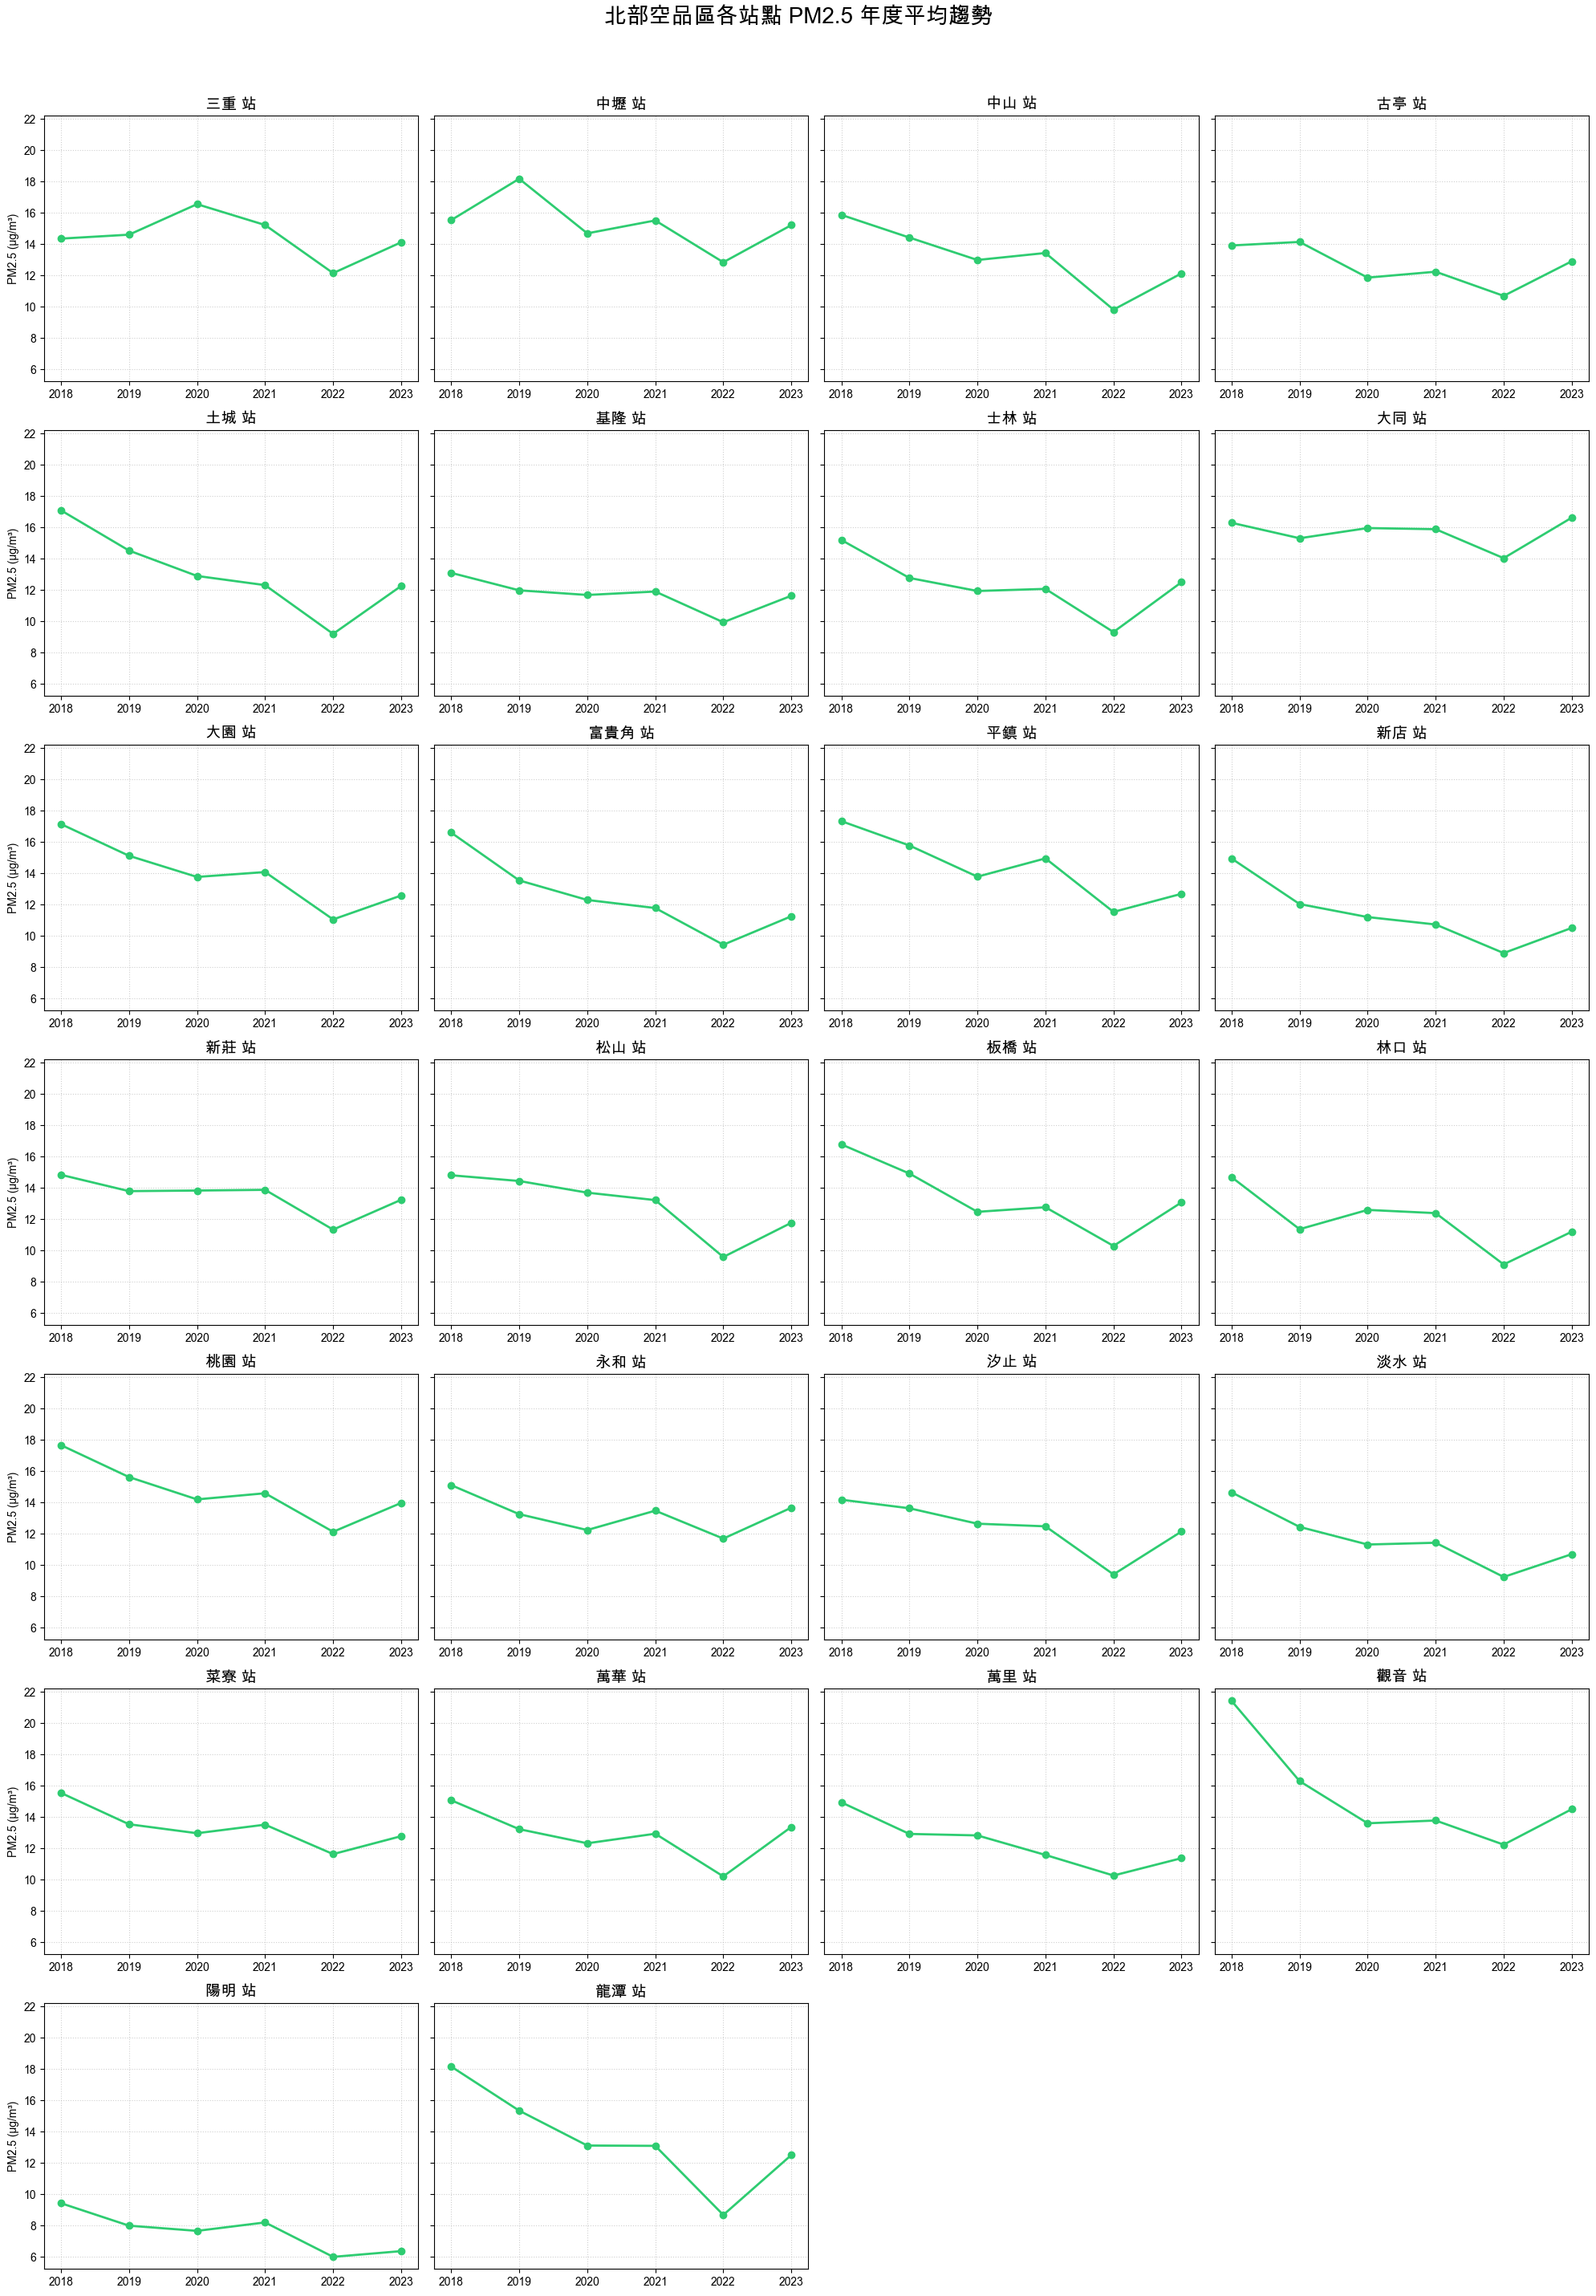

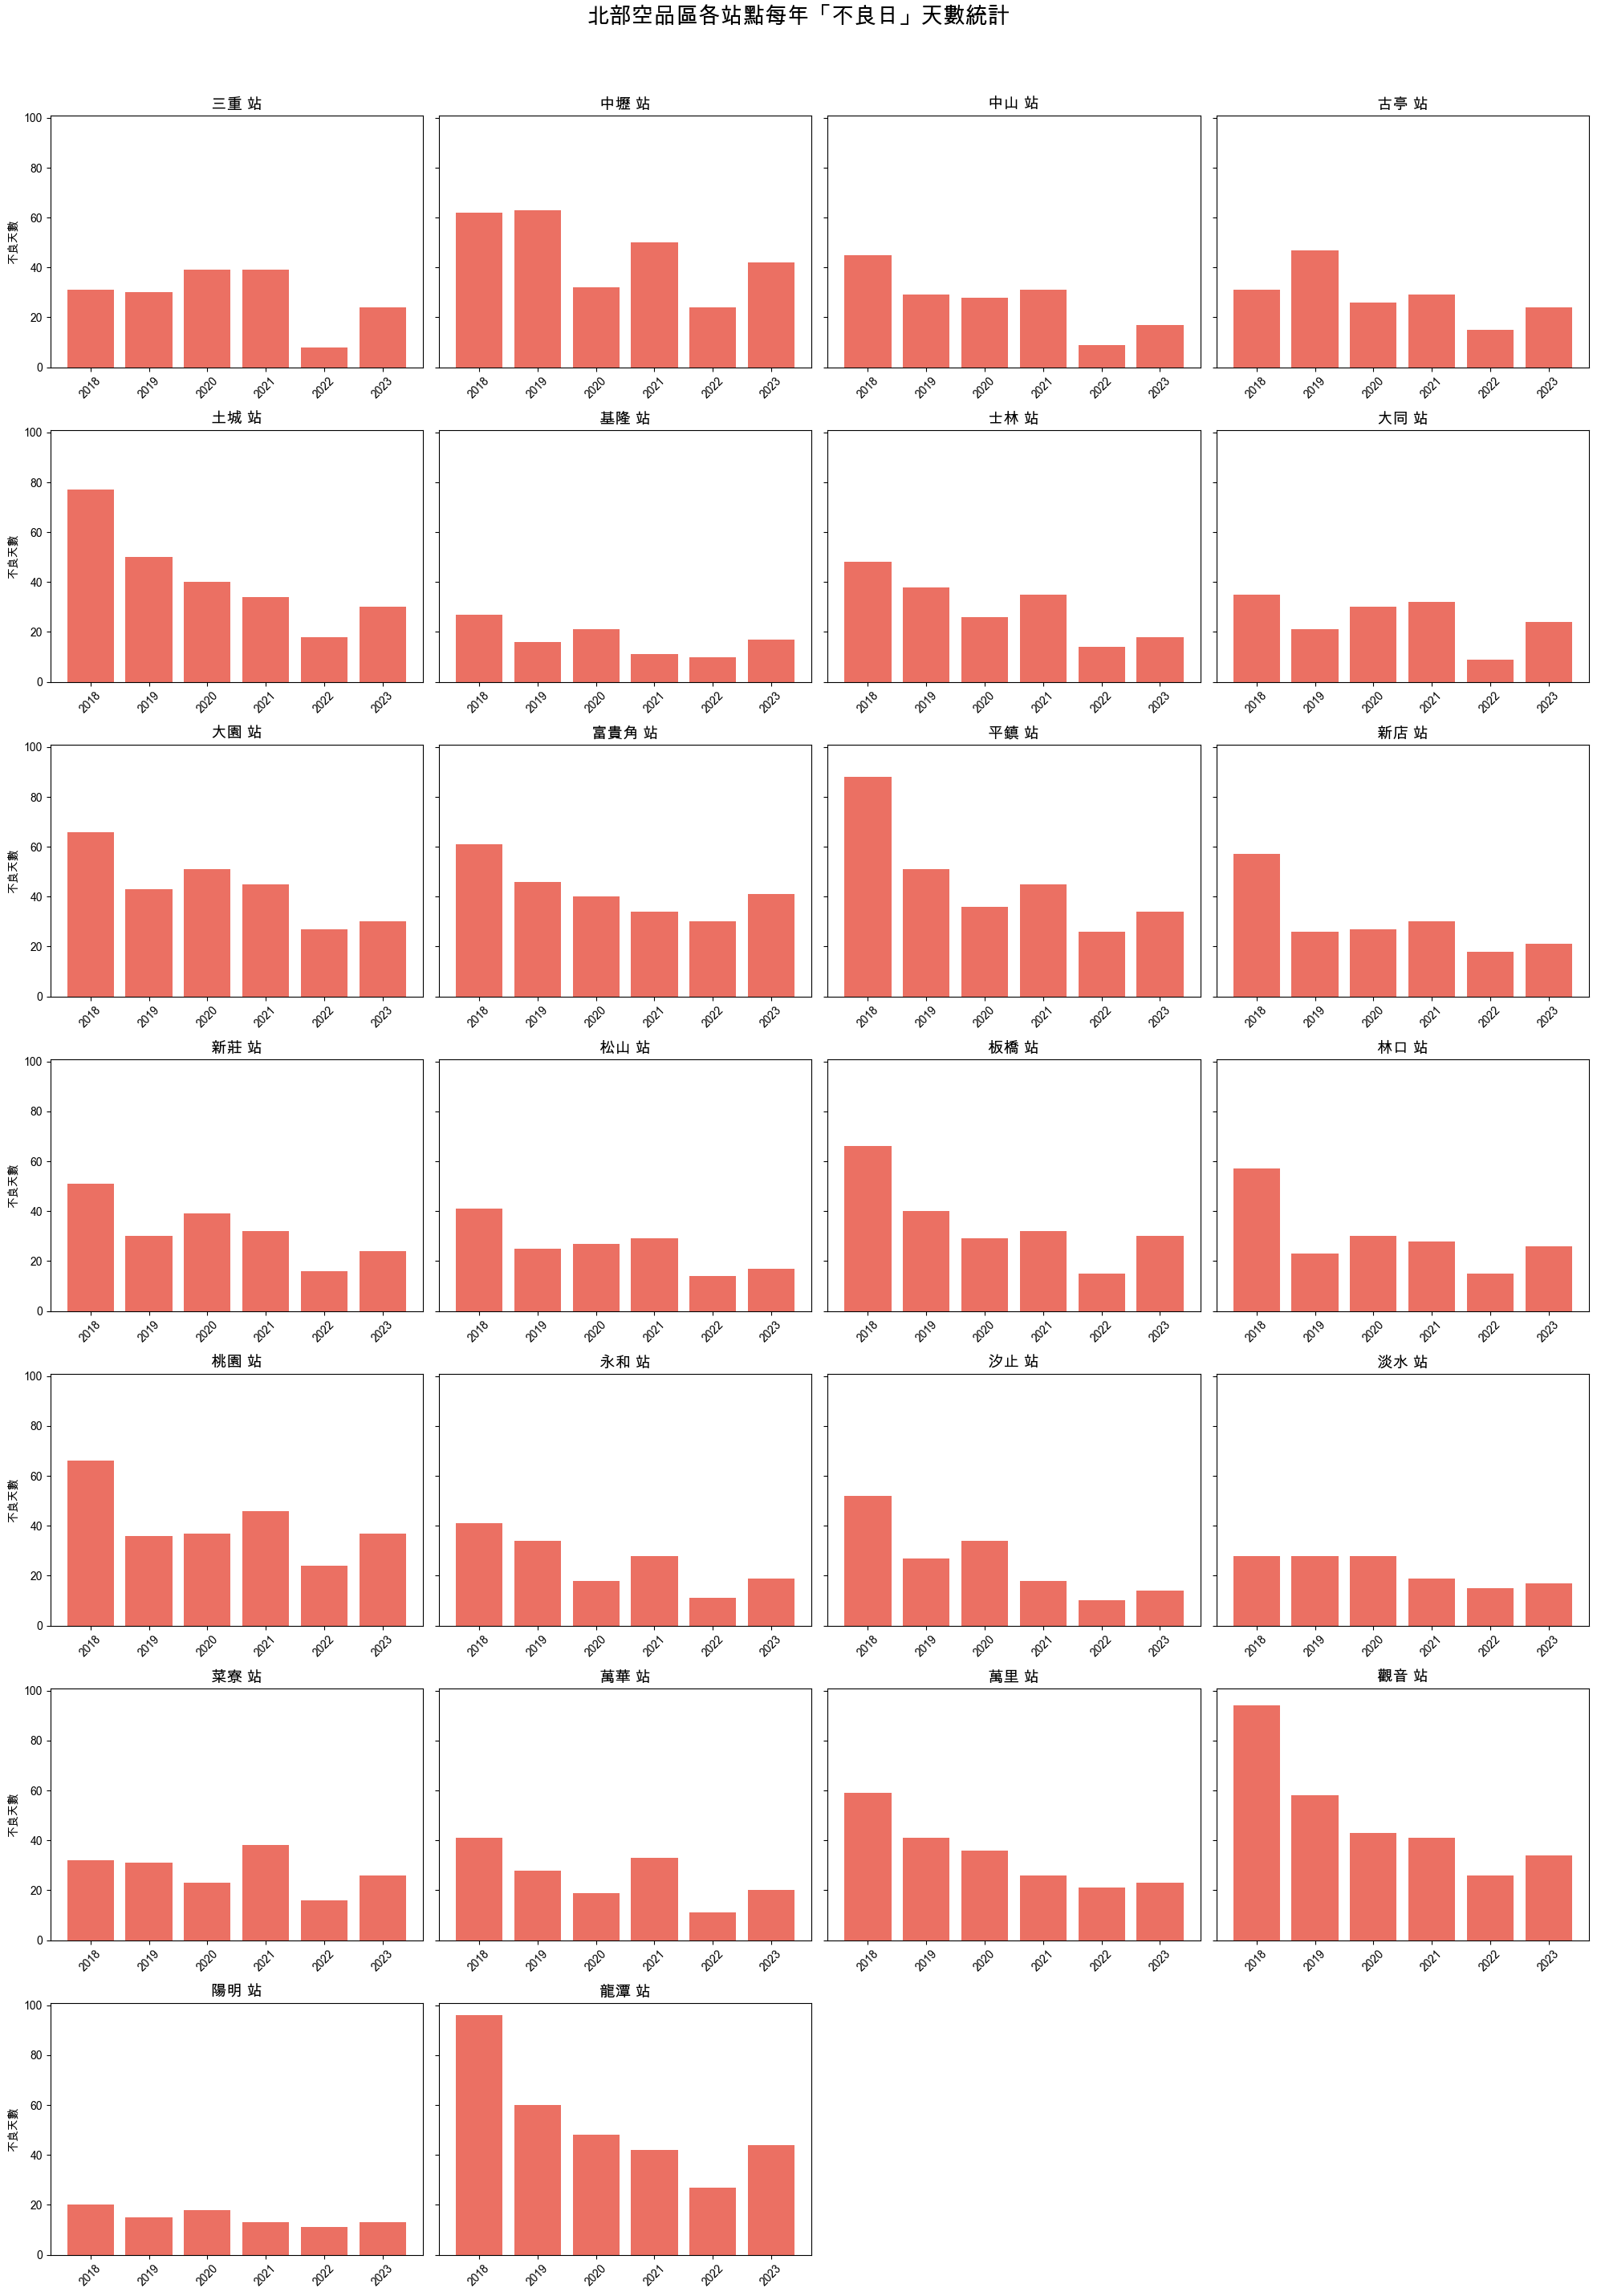

In [73]:
import matplotlib.pyplot as plt
import seaborn as sns

def generate_facet_plots(df):
    plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']
    plt.rcParams['axes.unicode_minus'] = False # 設定負號顯示（讓負號不變方塊）
    
    # 1. 準備資料與網格設定
    df['Timestamp'] = pd.to_datetime(df['Timestamp'])
    df['Year'] = df['Timestamp'].dt.year
    stations = sorted(df['Station'].unique()) # 取得所有測站名稱並排序，unique() 會返回不重複的測站名稱，sorted() 會將它們按字母順序排列
    n_stations = len(stations)
    cols = 4
    rows = (n_stations // cols) + (1 if n_stations % cols != 0 else 0)

    # 年度趨勢 (一站一格) 
    fig1, axes1 = plt.subplots(rows, cols, figsize=(20, rows * 4), sharey=True)
    # fig1: 整張大圖物件（控制總標題、整體尺寸）
    # axes1: 包含所有小圖的陣列（透過索引 axes1[i] 存取每一格，sharey 確保所有小圖 Y 軸刻度一致）
    # 產生畫布與子圖矩陣 (預設為 rows x cols 的二維陣列)

    axes1 = axes1.flatten()
    # 將二維陣列展平為一維
    
    # 先算出平均值，避免在迴圈內做重疊繪圖
    annual_data = df.groupby(['Year', 'Station'])['PM2.5'].mean().reset_index()

    for i, station in enumerate(stations):
    # enumerate(stations) 會返回 (index, station) 的組合，index 從 0 開始，station 是測站名稱
        data = annual_data[annual_data['Station'] == station]
        axes1[i].plot(data['Year'], data['PM2.5'], marker='o', color='#2ecc71', linewidth=2)
        axes1[i].set_title(f'{station} 站', fontsize=14)
        axes1[i].grid(True, linestyle=':', alpha=0.6)
        if i % cols == 0: axes1[i].set_ylabel('PM2.5 (μg/m³)')
    
    # 隱藏多餘格子
    for j in range(len(stations), len(axes1)): axes1[j].axis('off')
    fig1.suptitle('北部空品區各站點 PM2.5 年度平均趨勢', fontsize=20, y=1.02)
    fig1.tight_layout()

    # 年度不良日統計 (一站一格) 
    fig2, axes2 = plt.subplots(rows, cols, figsize=(20, rows * 4), sharey=True)
    axes2 = axes2.flatten()

    # 算日平均 AQI > 100
    daily_aqi = df.groupby(['Year', 'Station', df['Timestamp'].dt.date])['AQI'].max().reset_index()
    # 依照年、站點、日期（去除小時只留日期）分組，計算每天的最高 AQI，並重置索引以便後續處理

    bad_days_df = daily_aqi[daily_aqi['AQI'] > 100].groupby(['Year', 'Station']).size().reset_index(name='BadDays')
    # 篩選出 AQI > 100 的日子，並依年、站點分組計算不良日的數量，重置索引並命名為 'BadDays'

    for i, station in enumerate(stations):
        data = bad_days_df[bad_days_df['Station'] == station]
        axes2[i].bar(data['Year'].astype(str), data['BadDays'], color='#e74c3c', alpha=0.8)
        axes2[i].set_title(f'{station} 站', fontsize=14)
        if i % cols == 0: axes2[i].set_ylabel('不良天數')
        axes2[i].tick_params(axis='x', rotation=45)
    
    for j in range(len(stations), len(axes2)): axes2[j].axis('off')
    fig2.suptitle('北部空品區各站點每年「不良日」天數統計', fontsize=20, y=1.02)
    fig2.tight_layout()
    
    plt.show()

# 執行
generate_facet_plots(df)

/var/folders/17/vsmmd5dx5pv74fwy86w422940000gn/T/ipykernel_40220/18905681.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Month', y='PM2.5', data=df, palette='viridis', showfliers=False)


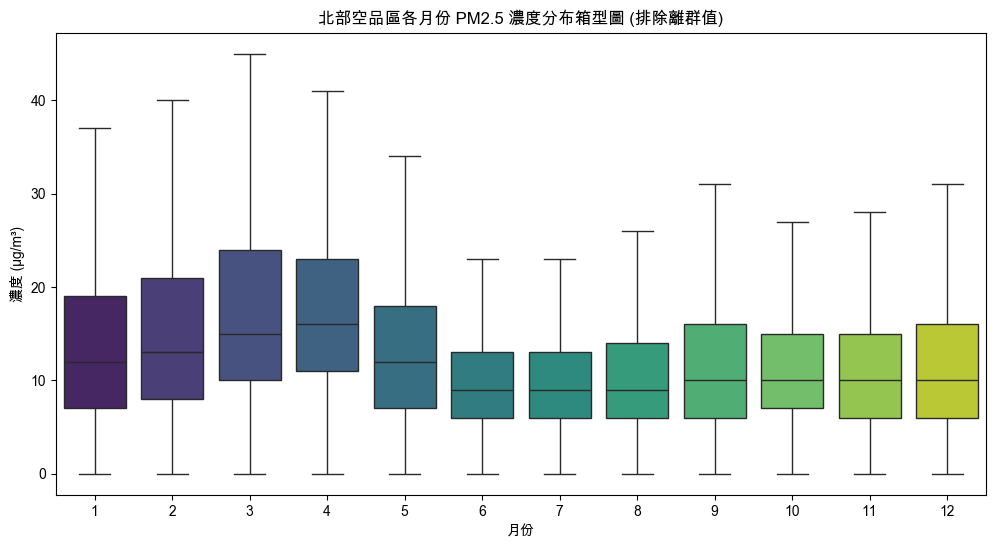

/var/folders/17/vsmmd5dx5pv74fwy86w422940000gn/T/ipykernel_40220/18905681.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Hour', y='PM2.5', data=df, palette='coolwarm', showfliers=False)


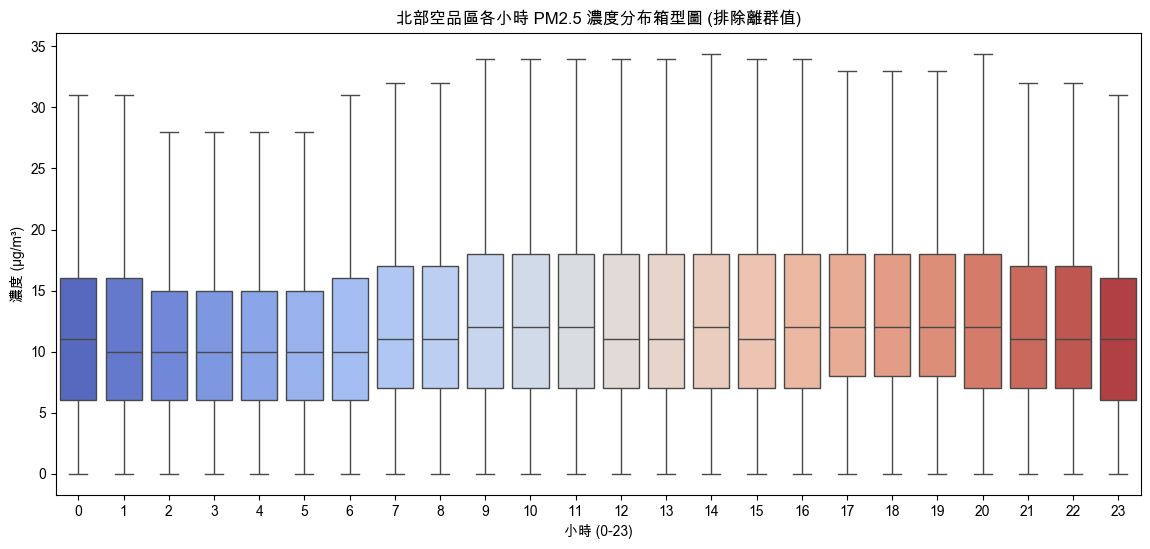

In [74]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def generate_advanced_plots(df):
    # 基礎設定
    plt.rcParams['font.sans-serif'] = ['Arial Unicode MS'] # Mac 字體
    plt.rcParams['axes.unicode_minus'] = False
    
    # 預處理時間欄位
    df['Timestamp'] = pd.to_datetime(df['Timestamp'])
    df['Year'] = df['Timestamp'].dt.year
    df['Month'] = df['Timestamp'].dt.month
    df['Hour'] = df['Timestamp'].dt.hour

    # --- 第三張圖：北部空品區各月份的污染物濃度箱型圖 ---
    plt.figure(figsize=(12, 6))
    sns.boxplot(x='Month', y='PM2.5', data=df, palette='viridis', showfliers=False)
    plt.title('北部空品區各月份 PM2.5 濃度分布箱型圖 (排除離群值)')
    plt.xlabel('月份')
    plt.ylabel('濃度 (μg/m³)')
    plt.show()

    # --- 第四張圖：北部空品區各小時的污染物濃度箱型圖 ---
    plt.figure(figsize=(14, 6))
    sns.boxplot(x='Hour', y='PM2.5', data=df, palette='coolwarm', showfliers=False)
    plt.title('北部空品區各小時 PM2.5 濃度分布箱型圖 (排除離群值)')
    plt.xlabel('小時 (0-23)')
    plt.ylabel('濃度 (μg/m³)')
    plt.show()

# 執行繪圖
generate_advanced_plots(df)